In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

In [2]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML
from src.Skeleton_model.stgcn import STGCN
from src.XAI.rise import RISE
from src.rwf2000 import RWF2000Dataset, RWF2000PoseDataset
from src.config import POSE_DATASET_ROOT_OCSORT2
from src.config import CHECKPOINT_DIR
from src.XAI.plotting_functions import plot_gradcam_over_rgb, plot_single_frame_gradcam, animate_saliency_over_rgb
from src.Skeleton_model.graph import SkeletonGraph, compute_joint_distance_to_center_of_gravity
from scripts.common.get_device import get_available_device


dataset_root = POSE_DATASET_ROOT_OCSORT2

experiment_root = CHECKPOINT_DIR / "STGCN_V1" / "final_test_amsgrad" / "amsgrad_false"
device = get_available_device()

with open(experiment_root / "config.json", "r") as f:
    hyperparameters = json.load(f)

radii_dataset = RWF2000PoseDataset(dataset_root, split="train", max_people=hyperparameters["max_people"], score_mode=hyperparameters["score_mode"])
radii = compute_joint_distance_to_center_of_gravity(radii_dataset)
skeleton_graph = SkeletonGraph(radii, normalisation=hyperparameters["adjacency_normalisation_mode"])
model = STGCN(skeleton_graph.A, temporal_kernel_size=hyperparameters["temporal_kernel_size"], dropout=hyperparameters["dropout"], edge_importance_weighting=hyperparameters["edge_importance_weighting"], people_aggregation=hyperparameters["people_aggregation"]).to(device)

checkpoint = torch.load(experiment_root / "best_model.pt", map_location=device)

if "model_state_dict" in checkpoint:
    model.load_state_dict(checkpoint["model_state_dict"])
else:
    model.load_state_dict(checkpoint)

model.to(device)
model.eval()

val_dataset = RWF2000PoseDataset(dataset_root, split="val", max_people=hyperparameters["max_people"], score_mode=hyperparameters["score_mode"])

video_num = 300
video, label = val_dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 3, 150, 17, 4]

label = label.item()

Using cuda:0 with 20.80 GB free


/mnt/vurm/homes/homes/mp2940/violence-detection-dissertation/src/Skeleton_model/graph.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.radii = torch.tensor(radii, dtype=torch.float32)


In [7]:
from src.XAI.rise import SkeletonRise
from src.XAI.insertion_deletion_auc import AUC_TEST
video_num = 300
video, label = val_dataset[video_num]
video_batch = video.unsqueeze(0).to(device)
# [1, 3, 150, 17, 4]

label = label.item()
rise = SkeletonRise(model, num_masks=10000)
output = rise.generate_heatmap(video_batch)
normalised_saliency_map = output[1]
print(f"normalised saliency_map shape: {normalised_saliency_map.shape}")

processed 8/10000 masks
processed 16/10000 masks
processed 24/10000 masks
processed 32/10000 masks
processed 40/10000 masks
processed 48/10000 masks
processed 56/10000 masks
processed 64/10000 masks
processed 72/10000 masks
processed 80/10000 masks
processed 88/10000 masks
processed 96/10000 masks
processed 104/10000 masks
processed 112/10000 masks
processed 120/10000 masks
processed 128/10000 masks
processed 136/10000 masks
processed 144/10000 masks
processed 152/10000 masks
processed 160/10000 masks
processed 168/10000 masks
processed 176/10000 masks
processed 184/10000 masks
processed 192/10000 masks
processed 200/10000 masks
processed 208/10000 masks
processed 216/10000 masks
processed 224/10000 masks
processed 232/10000 masks
processed 240/10000 masks
processed 248/10000 masks
processed 256/10000 masks
processed 264/10000 masks
processed 272/10000 masks
processed 280/10000 masks
processed 288/10000 masks
processed 296/10000 masks
processed 304/10000 masks
processed 312/10000 masks

In [8]:
auc_test = AUC_TEST(model=model,data_type="skeleton")

In [9]:
fractions, scores, auc = auc_test.deletion(video_batch, saliency_map=normalised_saliency_map)

<Axes: xlabel='Fraction of locations perturbed', ylabel='Target class probability'>

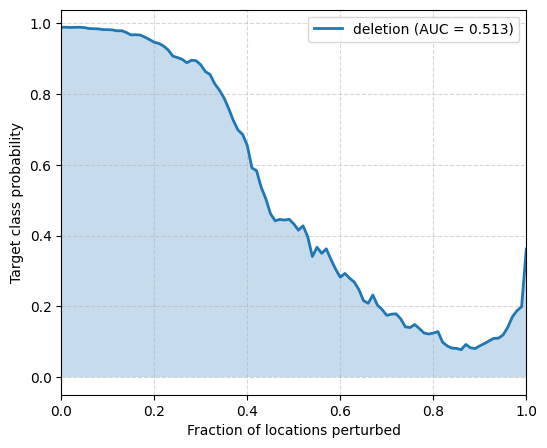

In [10]:
AUC_TEST.plot_auc_curve(fractions, scores, auc, "deletion")